In [2]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

plt.rcParams["figure.figsize"] = (24, 12)

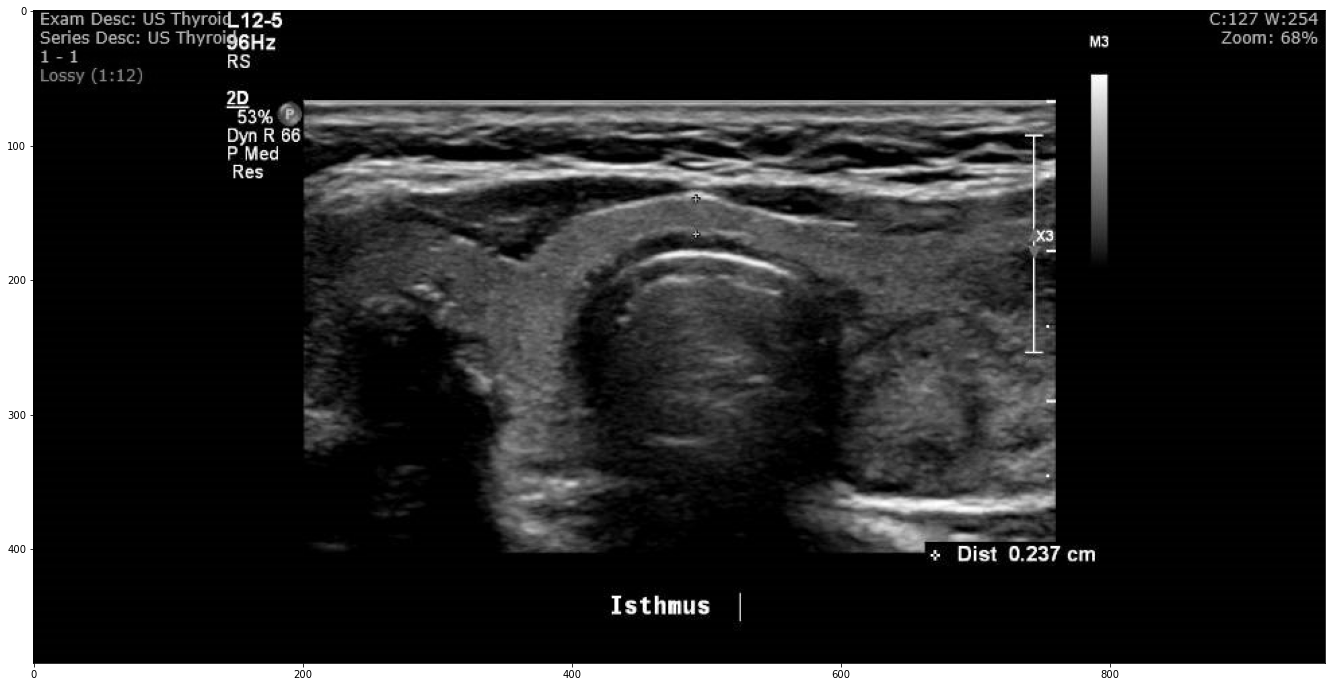

In [3]:
def load_original_image(image_path):
    img = cv2.imread(image_path, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img_rgb

image_path = os.path.join('A:\\', '255', '1.png')
image_array = load_original_image(image_path)
plt.imshow(image_array, 'gray')
plt.show()

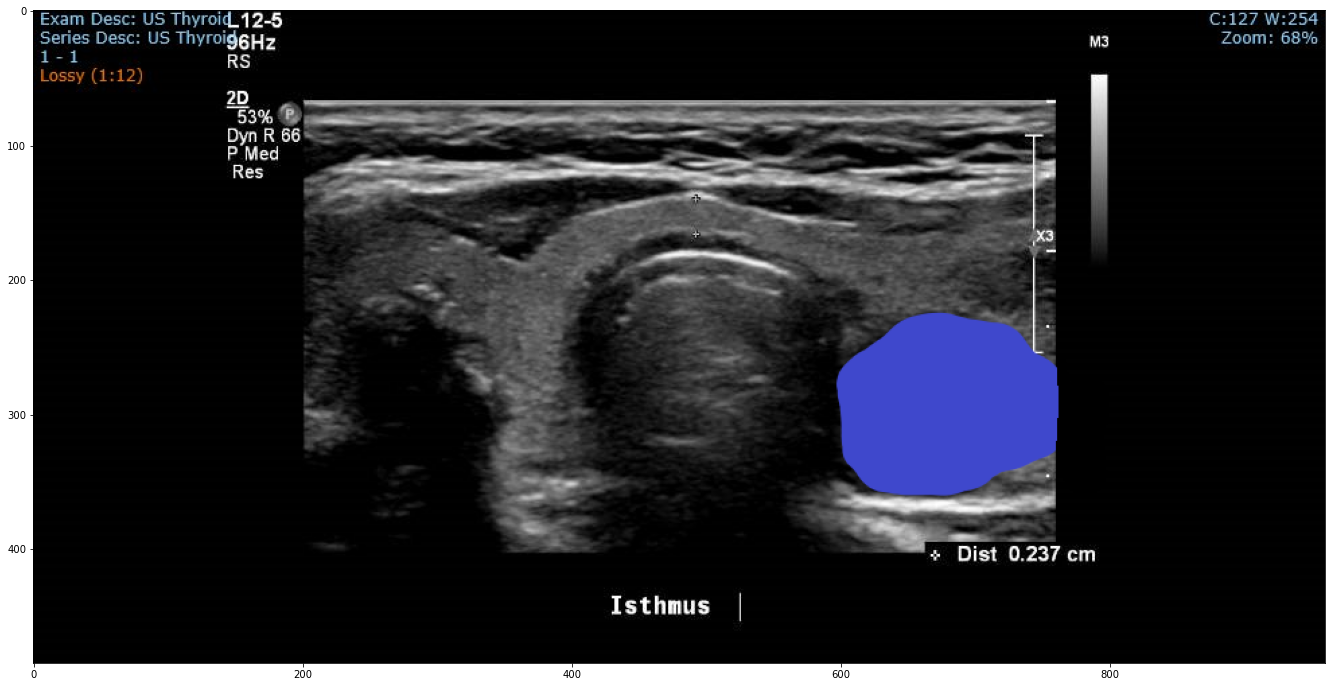

In [4]:
def load_edited_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return RGB_img

image_path = os.path.join('A:\\', '255', '1n2.png')
image_array = load_edited_image(image_path)
plt.imshow(image_array)
plt.show()

In [5]:
# Cropping Constants
BINARY_THRESHOLD = 1
RUN_THRESHOLD = 0.18
MIN_HEIGHT = 300

# Artifacts Constants
ARTIFACT_INTENSITY = 220

In [6]:
def load_image(image_path):
    img = cv2.imread(image_path, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img_rgb

def crop_image(image_array, window_size):
    ultrasound_image = find_ultrasound_image(image_array)
    cropped_image = standardize_size(ultrasound_image, window_size)
    return cropped_image

def remove_artifacts(cropped_image):
    artifact_flags = cropped_image >= ARTIFACT_INTENSITY
    artifact_idx = np.where(artifact_flags)
    artifact_idx_list = []
    for i, y in enumerate(artifact_idx[0]):
        x = artifact_idx[1][i]
        artifact_idx_list.append((y, x, cropped_image[y, x]))
    artifact_idx_list.sort(key=lambda tup: tup[2], reverse=False)
    for y, x, _ in artifact_idx_list:
        local_region = cropped_image[(y-1):(y+2), (x-1):(x+2)]
        background_mean = np.mean(sorted(local_region.flatten())[:6])
        cropped_image[y, x] = background_mean
    return cropped_image

def find_ultrasound_image(image_array):
    binary_mask = np.zeros(image_array.shape)
    binary_mask[image_array > BINARY_THRESHOLD] = 1.
    
    row_mean = np.mean(binary_mask, axis=0)
    col_mean = np.mean(binary_mask, axis=1)
    
    row_runs = get_bidirectional_runs(row_mean)
    col_runs = get_bidirectional_runs(col_mean)
    
    row_indices = np.where(row_runs >= np.max(row_runs)*0.75)[0]
    left_bound = row_indices[0]
    right_bound = row_indices[-1]
    col_indices = np.where(col_runs >= np.max(col_runs)*0.75)[0]
    up_bound = col_indices[0]
    down_bound = max(col_indices[-1], up_bound + MIN_HEIGHT)
    cropped_image = image_array[up_bound:down_bound, left_bound:right_bound]
    
    return cropped_image

def standardize_size(ultrasound_image, window_size):
    resized_image = np.zeros(window_size)
    horizontal_boundary = int((window_size[1] - ultrasound_image.shape[1])/2)
    vertical_boundary = int((window_size[0] - ultrasound_image.shape[0])/2)
    resized_image[vertical_boundary:(vertical_boundary+ultrasound_image.shape[0]), 
                  horizontal_boundary:(horizontal_boundary+ultrasound_image.shape[1])] = ultrasound_image
    return resized_image

def get_bidirectional_runs(mean_vector):
    forward_runs = get_runs(mean_vector)
    backward_runs = get_runs(mean_vector[::-1])[::-1]
    bidirectional_runs = forward_runs + backward_runs
    return bidirectional_runs

def get_runs(numeric_vector):
    runs = np.empty(len(numeric_vector), dtype=np.int16)
    curr = 0
    for i, x in enumerate(numeric_vector):
        if x > RUN_THRESHOLD:
            curr += 1
        else:
            curr = 0
        runs[i] = curr
    return runs

def represents_int(s):
    try: 
        int(s)
        return True
    except ValueError:
        return False

In [7]:
data_path = os.path.join('A:\\')
samples = os.listdir(data_path)

window_size = (512, 768)
X = np.zeros((210, *window_size))
i = 0
for sample in samples:
    sample_path = os.path.join(data_path, sample)
    filenames = os.listdir(sample_path)
    for filename in filenames:
        if represents_int(filename[:-4]):
            image_path = os.path.join(sample_path, filename)
            image_array = load_image(image_path)
            cropped_image = crop_image(image_array, window_size)
            cleaned_image = remove_artifacts(cropped_image)
            X[i] = cleaned_image
            i += 1
X = X[:i]

In [8]:

X.shape
 

(111, 512, 768)

In [9]:
import tensorflow as tf
from keras.models import Sequential
import pandas as pd
from keras.layers import Dense

In [10]:
import csv
import os
import pandas as pd

df=pd.read_csv(os.path.join(r'C:\Users\chery\Downloads\thyroid','aggregate.csv'))
print(df)

    sample_id image            machine     lobe          view     position  \
0         255   1n2            Epiq 7G  Isthmus    Transverse          NaN   
1         255   2n2            Epiq 7G  Isthmus    Transverse          NaN   
2         255   3n1            Epiq 7G    Right  Longitudinal          NaN   
3         255   5n1            Epiq 7G    Right  Longitudinal  Upper - mid   
4         255   6n1            Epiq 7G    Right  Longitudinal  Upper - mid   
..        ...   ...                ...      ...           ...          ...   
72        295   9n1  Toshiba Aplio 500     Left  Longitudinal  Mid - lower   
73        295  10n1  Toshiba Aplio 500     Left    Transverse  Mid - lower   
74        295  11n1  Toshiba Aplio 500     Left    Transverse  Mid - lower   
75        295  12n1  Toshiba Aplio 500     Left    Transverse  Mid - lower   
76        295  13n1  Toshiba Aplio 500     Left    Transverse          Mid   

   nodule_id nodule_side nodule_location          size_cm  ... 

In [11]:
sample_id=df.sample_id
image=df.image
rows=len(image)

window_size = (512, 768)
x = np.zeros((rows, *window_size))

for i in range(rows):
    
    #x data (the images)
    newstr=""
    for j in str(image[i]):
        if(j=="n"):
            break
        else:
            newstr+=j
    image_path=os.path.join(r'A:\\', str(sample_id[i]), newstr+'.png')
    image_array = load_image(image_path)
    cropped_image = crop_image(image_array, window_size)
    cleaned_image = remove_artifacts(cropped_image)
    x[i]=cleaned_image
#     plt.imshow(cleaned_image,'gray')
#     plt.show()

x=x/255.0

In [12]:
margin_score=df.margin_score
#print(margin_score)
y=pd.DataFrame(margin_score).to_numpy()

for i in range(len(margin_score)): #margin score is 2 or 0 (2 ==yes)
    if y[i]==2.:
        y[i]=1.
    
#print(y)


In [13]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

train_ratio = 0.70
validation_ratio = 0.15
test_ratio = 0.15

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1-train_ratio, random_state=45)

x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio), random_state=43) 

In [14]:
x_train = tf.expand_dims(x_train, axis=-1)
x_val = tf.expand_dims(x_val, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)


#print(x_train.shape)
#print(y_train.shape)
#print(x_test.shape)
#print(y_test.shape)

In [15]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2

In [16]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.Conv2D(16, kernel_size=(5,5), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(32, kernel_size=(7,7), activation='relu'),
    tf.keras.layers.Conv2D(64, kernel_size=(7,7), activation='relu', kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [17]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [18]:
model.compile(tf.keras.optimizers.Adam(learning_rate=3e-4), 
              loss=loss_fn,
              metrics=['accuracy'])

In [19]:
model.fit(x_train, y_train, epochs=5, batch_size=4, shuffle=True, validation_data=(x_val, y_val))

Epoch 1/5
14/14 [==============================] - 110s 7s/step - loss: 1.3877 - accuracy: 0.5660 - val_loss: nan - val_accuracy: 0.3333
Epoch 2/5
14/14 [==============================] - 104s 7s/step - loss: 0.8325 - accuracy: 0.8113 - val_loss: nan - val_accuracy: 0.8333
Epoch 3/5
14/14 [==============================] - 99s 7s/step - loss: 0.4943 - accuracy: 0.9245 - val_loss: nan - val_accuracy: 0.8333
Epoch 4/5
14/14 [==============================] - 103s 7s/step - loss: 0.2882 - accuracy: 1.0000 - val_loss: nan - val_accuracy: 0.6667
Epoch 5/5
14/14 [==============================] - 993s 76s/step - loss: 0.2263 - accuracy: 1.0000 - val_loss: nan - val_accuracy: 0.6667


In [20]:
#model.fit(x_train, y_train, validation_split=0.2, epochs=10, shuffle=True)


In [21]:
#loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

#model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])

In [22]:
#model.fit(x_train, y_train, epochs=5, batch_size=4, shuffle=True, validation_data=(x_val, y_val))


In [ ]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    epochs=2,
    # We pass some validation for
    # monitoring validation loss and metrics
    # at the end of each epoch
    validation_split=0.1,
)

Fit model on training data
Epoch 1/2
2/2 [==============================] - 81s 28s/step - loss: 0.2132 - accuracy: 1.0000 - val_loss: 0.2103 - val_accuracy: 1.0000
Epoch 2/2
1/2 [==============>...............] - ETA: 51s - loss: 0.2106 - accuracy: 1.0000

In [ ]:
history.history

In [ ]:
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
print(x_test,y_test)
results = model.evaluate(x_test, y_test)
print("test loss, test acc:", results)

# Generate predictions (probabilities -- the output of the last layer)
# on new data using `predict`
print("Generate predictions for 3 samples")
predictions = model.predict(x_test[:3])
print("predictions shape:", predictions.shape)